# Reinforcement Learning : Finetuning HalfCheetah-v5 with DPO from trajectory preferences

In this assignment, we will fine-tune an RL modle that controls HalfCheetah-v5 model using DPO from trajectory preferences. You will finetune the model to walk and run forward.

## Problem Description
The HalfCheetah-v5 environment is part of the Mujoco environments in https://gymnasium.farama.org/environments/mujoco/half_cheetah/.

[![/assets/half_cheetah_title.gif](./assets/half_cheetah_title.gif)](./assets/half_cheetah_title.gif)
|                 |                                |
|-----------------|--------------------------------|
|Action Space     |Box(-1.0, 1.0, (6,), float32)   |
|Observation Space|Box(-inf, inf, (17,), float64)  |
|import           |gymnasium.make("HalfCheetah-v5")|


Description
---------------------------------------------------

This environment is based on the work of P. Wawrzyński in [“A Cat-Like Robot Real-Time Learning to Run”](http://staff.elka.pw.edu.pl/~pwawrzyn/pub-s/0812_LSCLRR.pdf). The HalfCheetah is a 2-dimensional robot consisting of 9 body parts and 8 joints connecting them (including two paws). The goal is to apply torque to the joints to make the cheetah run forward (right) as fast as possible, with a positive reward based on the distance moved forward and a negative reward for moving backward. The cheetah’s torso and head are fixed, and torque can only be applied to the other 6 joints over the front and back thighs (which connect to the torso), the shins (which connect to the thighs), and the feet (which connect to the shins).

Action Space
-----------------------------------------------------

![./assets/half_cheetah.png](./assets/half_cheetah.png)

The action space is a `Box(-1, 1, (6,), float32)`. An action represents the torques applied at the hinge joints.
| Num | Action                                  | Control Min | Control Max |  Joint | Type (Unit)  |
| --: | --------------------------------------- | ----------: | ----------: |  ----- | ------------ |
|   0 | Torque applied on the back thigh rotor  |          -1 |           1 |  hinge | torque (N m) |
|   1 | Torque applied on the back shin rotor   |          -1 |           1 |  hinge | torque (N m) |
|   2 | Torque applied on the back foot rotor   |          -1 |           1 |  hinge | torque (N m) |
|   3 | Torque applied on the front thigh rotor |          -1 |           1 |  hinge | torque (N m) |
|   4 | Torque applied on the front shin rotor  |          -1 |           1 |  hinge | torque (N m) |
|   5 | Torque applied on the front foot rotor  |          -1 |           1 |  hinge | torque (N m) |



Observation Space
---------------------------------------------------------------

The observation space consists of the following parts (in order):
*   _qpos (8 elements by default):_ Position values of the robot’s body parts.
*   _qvel (9 elements):_ The velocities of these individual body parts (their derivatives).
By default, the observation space is a `Box(-Inf, Inf, (17,), float64)` where the elements are as follows:

| Num | Observation                               | Min  | Max | Joint | Type (Unit)              |
| --: | ----------------------------------------- | ---- | --- | ----- | ------------------------ |
|   0 | z-coordinate of the front tip             | -Inf | Inf | slide | position (m)             |
|   1 | angle of the front tip                    | -Inf | Inf | hinge | angle (rad)              |
|   2 | angle of the back thigh                   | -Inf | Inf | hinge | angle (rad)              |
|   3 | angle of the back shin                    | -Inf | Inf | hinge | angle (rad)              |
|   4 | angle of the back foot                    | -Inf | Inf | hinge | angle (rad)              |
|   5 | angle of the front thigh                  | -Inf | Inf | hinge | angle (rad)              |
|   6 | angle of the front shin                   | -Inf | Inf | hinge | angle (rad)              |
|   7 | angle of the front foot                   | -Inf | Inf | hinge | angle (rad)              |
|   8 | velocity of the x-coordinate of front tip | -Inf | Inf | slide | velocity (m/s)           |
|   9 | velocity of the z-coordinate of front tip | -Inf | Inf | slide | velocity (m/s)           |
|  10 | angular velocity of the front tip         | -Inf | Inf | hinge | angular velocity (rad/s) |
|  11 | angular velocity of the back thigh        | -Inf | Inf | hinge | angular velocity (rad/s) |
|  12 | angular velocity of the back shin         | -Inf | Inf | hinge | angular velocity (rad/s) |
|  13 | angular velocity of the back foot         | -Inf | Inf | hinge | angular velocity (rad/s) |
|  14 | angular velocity of the front thigh       | -Inf | Inf | hinge | angular velocity (rad/s) |
|  15 | angular velocity of the front shin        | -Inf | Inf | hinge | angular velocity (rad/s) |
|  16 | angular velocity of the front foot        | -Inf | Inf | hinge | angular velocity (rad/s) |

In [1]:
# Import libraries and environmental parameters
import numpy as np
import torch
from IPython import display
import torch.nn as nn
from collections import deque
import numpy as np
import torch
import random
import json
import gymnasium as gym
from preference import cheetah_trajectory_score

STATE_DIM = 17
ACTION_DIM = 6
EP_LEN = 200

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
env = gym.make("HalfCheetah-v5", max_episode_steps=EP_LEN)
env.reset(seed=0)
SEED = [33, 81, 41, 31, 83]

In [2]:
# Preparation of actor network and environment simulation

class ContinuousMLP(nn.Module):
    # Actor network for continuous state and action spaces
    def __init__(self, state_dim: int = 17, action_dim: int = 6, hidden_dim: int = 64):
        """
        defines the actor network architecture
        :param state_dim: the observation space dimension
        :param action_dim: the action space dimension
        :param hidden_dim: the hidden layer dimension
        """
        super().__init__()
        self.fc1 = nn.Linear(in_features=state_dim, out_features=hidden_dim)
        self.fc2 = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
        self.fc3 = nn.Linear(in_features=hidden_dim, out_features=action_dim)
        self._init_weights()
        self.log_std = nn.Parameter(torch.full((action_dim,), -0.5))

    def _init_weights(self, mean=0.0, std=1.0):
        """
        initialize the weights of the network with a normal distribution
        :param mean: mean of the normal distribution
        :param std: std of the normal distribution
        :return:
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=mean, std=std)
                nn.init.normal_(m.bias, mean=mean, std=std)  # or normal_ if you want biases randomized too

    def forward(self, state):
        """
        forward pass of the network
        :param state: the observation batch of shape (batch_size, state_dim)
        :return: logits representing the mean of action distribution and std of action distribution
        """
        scale1 = float(self.fc1.in_features) ** 0.5
        scale2 = float(self.fc2.in_features) ** 0.5
        scale3 = float(self.fc3.in_features) ** 0.5
        x = torch.tanh(self.fc1(state) / scale1)
        x = torch.tanh(self.fc2(x) / scale2)
        logits = self.fc3(x) / scale3
        std = torch.exp(self.log_std).clamp(1e-3, 10.0)
        return logits, std

def simulate(model, env, deterministic=False, seed=None, actor=None):
    """
    simulate the environment with the actor model (base, dpo, szpo)
    :param model: class inherenting the base model
    :param env: halfcheetah-v5 gym environment
    :param deterministic: whether to use deterministic policy
    :param seed: seed for environment initialization
    :param actor: which actor in the model to use
    :return: reward_ep: episode reward, states: list of states, actions: list of actions, log_probs: list of log probabilities
    """
    actor = model.actor if actor is None else actor
    obs, _ = env.reset(seed=seed)
    max_steps = env.spec.max_episode_steps
    reward_ep = 0
    states = []
    actions = []
    log_probs = []
    for _ in range(max_steps):
        states.append(obs.tolist())
        action, log_prob = model.predict(obs, deterministic=deterministic, actor=actor)
        actions.append(action.tolist())
        log_probs.append(float(log_prob))
        obs, reward, terminated, truncated, info = env.step(action)
        reward_ep += reward
        if truncated:
            break
    return reward_ep, states, actions, log_probs

def evaluate(model, env, deterministic=False, SEED=None):
    """
    evaluate the model on the environment
    :param model: class inherenting the base model
    :param env: halfcheetah-v5 gym environment
    :param deterministic: whether to use deterministic policy
    :param SEED: seed of seeds to initialize the environment, use [33, 81, 41, 31, 83] as default
    :return: value: mean episode reward
    """
    max_steps = env.spec.max_episode_steps
    rewards = []
    for seed in SEED:
        obs, _ = env.reset(seed=seed)
        reward_ep = 0
        for _ in range(max_steps):
            action, log_prob = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            reward_ep += reward
            if truncated:
                break
        rewards.append(reward_ep)
    value = np.array(rewards)
    return value

def visualize(model, env):
    obs, info = env.reset(seed=31)
    fig, ax = plt.subplots()
    img = ax.imshow(env.render())
    ax.axis("off")

    reward_ep = 0.0
    for _ in range(EP_LEN):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        reward_ep += reward

        img.set_data(env.render())
        display.clear_output(wait=True)
        display.display(fig)

        if terminated or truncated:
            break

    plt.close(fig)
    return reward_ep

def sample_preference(model, env, num_of_pairs=5):
    """
    sample trajectories and query preferences from the imported preference function
    :param model: a dpo model
    :param env: a gym environment
    :param num_of_pairs: number of pairs of trajectories to sample, use 5 as default
    :return:
        trajs_p: list of trajectories preferred by human, same form as the input of DPO.train() function
        trajs_n: list of trajectories not preferred by human, same form as the input of DPO.train() function
    """
    trajs_p = []
    trajs_n = []
    for ep in range(num_of_pairs):
        seed = random.randint(0, 100)
        reward_0, states_0, actions_0, log_probs_0 = simulate(model, env, deterministic=False, seed=seed)
        reward_1, states_1, actions_1, log_probs_1 = simulate(model, env, deterministic=False, seed=seed)
        score_0 = cheetah_trajectory_score(np.array(states_0), env.unwrapped.dt)
        score_1 = cheetah_trajectory_score(np.array(states_1), env.unwrapped.dt)
        if score_0 > score_1:
            trajs_p.append([states_0, actions_0])
            trajs_n.append([states_1, actions_1])
        else:
            trajs_p.append([states_1, actions_1])
            trajs_n.append([states_0, actions_0])
    return trajs_p, trajs_n

In [3]:
# Algorithm class
class Base:
    def __init__(self, state_dim: int = 17, action_dim: int = 6, hidden_dim: int = 64, device=None):
        self.state_dim = state_dim          # dimension of the state space
        self.action_dim = action_dim        # dimension of the action space
        self.hidden_dim = hidden_dim        # hidden layer dimension
        self.eps = 1e-6
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") if device is None else device
        self.actor = ContinuousMLP(state_dim, action_dim, hidden_dim).to(self.device)       # actor network

    def save(self, pth):
        # save the actor network parameters to pth
        torch.save(self.actor.state_dict(), pth)

    def load(self, pth):
        # load the actor network parameters from pth
        self.actor.load_state_dict(torch.load(pth, map_location=self.device, weights_only=True))

    def predict(self, state, deterministic=False, actor=None):
        """
        predict the action and log probability of the action given the state using the actor network
        :param state: np.array of shape (state_dim,)
        :param deterministic: whether to use deterministic policy
        :param actor: actor network to use
        :return: action: np.array of shape (action_dim,) and log_prob: float
        """
        actor = self.actor if actor is None else actor
        state = torch.from_numpy(np.atleast_2d(state)).float().to(self.device)
        with torch.no_grad():
            mean, std = actor(state)
            if deterministic:
                dist = torch.distributions.Normal(mean, std)
                u = mean
                a = torch.tanh(u)
            else:
                dist = torch.distributions.Normal(mean, std)
                u = dist.sample()
                a = torch.tanh(u)
            log_prob_u = dist.log_prob(u).sum(dim=-1)
            log_det_tanh = torch.log(1.0 - a.pow(2) + self.eps).sum(dim=-1)
            log_prob = (log_prob_u - log_det_tanh).cpu().numpy().squeeze()
            action = a.cpu().numpy().squeeze()
        return action, log_prob

    def log_probs(self, states, actions, actor=None):
        """
        compute the log probability of the actions given the states using the actor network
        :param states: torch.tensor of shape (batch_size, state_dim)
        :param actions: torch.tensor of shape (batch_size, action_dim)
        :param actor: which actor network to use
        :return: log_probs: torch.tensor of shape (batch_size,)
        """
        actor = self.actor if actor is None else actor
        mean, std = actor(states)
        dist = torch.distributions.Normal(mean, std)

        a = torch.clamp(actions, -1.0 + self.eps, 1.0 - self.eps)
        u = torch.atanh(a)

        log_prob_u = dist.log_prob(u).sum(dim=-1)
        log_det_tanh = torch.log(1.0 - a.pow(2) + self.eps).sum(dim=-1)
        log_probs = log_prob_u - log_det_tanh
        return log_probs

    def freeze_feature_layers(self, actor=None, freeze_std=True):
        """
        freeze the feature layers of the actor network and only train the last layer's weight and bias
        :param actor: which actor network to use
        :param freeze_std: whether to freeze the std of the action distribution
        :return:
        """
        actor = self.actor if actor is None else actor
        for p in actor.parameters():
            p.requires_grad = False
        # Identify the last Linear layer in the actor
        last_linear = None
        for m in actor.modules():
            if isinstance(m, nn.Linear):
                last_linear = m
        trainable_names = []

        # Unfreeze the last layer's weight and bias (if found)
        if last_linear is not None:
            for name, p in actor.named_parameters():
                if (p is last_linear.weight) or (p is last_linear.bias):
                    p.requires_grad = True
                    trainable_names.append(name)

        # keep log_std trainable as part of the output head if not frozen
        if (not freeze_std) and hasattr(actor, 'log_std'):
            log_std_param = getattr(actor, 'log_std')
            if isinstance(log_std_param, torch.nn.Parameter):
                log_std_param.requires_grad = True
                # record its parameter name for return
                for name, p in actor.named_parameters():
                    if p is log_std_param and name not in trainable_names:
                        trainable_names.append(name)
                        break
        return trainable_names

    def trainable_params(self, net=None):
        # return the list of trainable parameters in the actor network
        net = self.actor if net is None else net
        return [p for p in net.parameters() if p.requires_grad]

    def parameters_to_vector(self, net=None):
        """
        return the vector representation of the trainable parameters in the actor network, in torch.tensor format
        :param net: which actor network to use
        :return: torch.tensor of shape (number of trainable parameters,)
        """
        net = self.actor if net is None else net
        ps = self.trainable_params(net)
        return nn.utils.parameters_to_vector(ps)

    def vector_to_parameters(self, vector, net=None):
        """
        set the trainable parameters in the actor network from the torch.tensor vector representation
        :param vector: torch.tensor of shape (number of trainable parameters,)
        :param net: which network to use
        :return:
        """
        net = self.actor if net is None else net
        ps = self.trainable_params(net)

        # safety check
        expected = sum(p.numel() for p in ps)
        if vector.numel() != expected:
            raise ValueError(f"Vector has {vector.numel()} elems, but trainable params need {expected}.")

        nn.utils.vector_to_parameters(vector, ps)

class DPO(Base):
    def __init__(self, state_dim: int = 17, action_dim: int = 6, hidden_dim: int = 64, device=None, batch_size = 64,
                 lr=3e-3, epochs=10, beta=0.01, target_kl = 0.01):
        Base.__init__(self, state_dim=state_dim, action_dim=action_dim, hidden_dim=hidden_dim, device=device)
        self.lr = lr                    # learning rate
        self.epochs = epochs            # number of epochs to for one policy update
        self.beta = beta                # coefficient for the KL divergence in objective
        self.batch_size = batch_size    # batch size
        self.target_kl = target_kl      # target KL divergence for early stopping

        self.actor_ref = ContinuousMLP(state_dim, action_dim, hidden_dim).to(self.device)       # reference actor network
        self.actor_ref.load_state_dict(self.actor.state_dict())
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=self.lr)                # optimizer for the actor network
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.actor_optim, mode='min', factor=0.3, patience=20)

    def freeze_feature_layers_for_all(self, freeze_std=False):
        # freeze the feature layers of both actor networks
        self.freeze_feature_layers(actor=self.actor, freeze_std=freeze_std)
        self.freeze_feature_layers(actor=self.actor_ref, freeze_std=freeze_std)

    def load(self, pth):
        #load the actor network parameters from pth
        Base.load(self, pth)
        self.actor_ref.load_state_dict(self.actor.state_dict())

    def train(self, trajs_p, trajs_n):
        """
        train the actor network using the DPO objective
        :param trajs_p: list of trajectories preferred by human
        :param trajs_n: list of trajectories not preferred by human
                    trajs_p and trajs_n are list of lists, each element, say trajs_p[0] is a list of two lists trajs_p[0][0] is a list of states (batch_size, state_dim) and trajs_p[0][1] is a list of actions (batch_size, state_dim) both in list format

        :return:
        """
        # convert list of trajectories to torch.tensor
        states_p = torch.tensor([traj[0] for traj in trajs_p], dtype=torch.float32, device=self.device)         # states from prefered trajectories
        states_n = torch.tensor([traj[0] for traj in trajs_n], dtype=torch.float32, device=self.device)         # states from not preferred trajectories
        actions_p = torch.tensor([traj[1] for traj in trajs_p], dtype=torch.float32, device=self.device)        # actions from prefered trajectories
        actions_n = torch.tensor([traj[1] for traj in trajs_n], dtype=torch.float32, device=self.device)        # actions from not preferred trajectories

        # states_p and states_n are torch.tensor of shape (num_of_trajs, max_steps, state_dim)
        # actions_p and actions_n are torch.tensor of shape (num_of_trajs, max_steps, action_dim)

        num_of_trajs = states_p.shape[0]        # number of trajectories
        max_steps = states_p.shape[1]           # number of steps in each trajectory

        # TO_DO: compute the log-probabilities of the actions in the trajectories under the reference policy
        #########################################################################################################
        # you must form two tensor matrices of shape (num_of_trajs, max_steps) for the log-probabilities of the actions in the trajectories under the reference policy. each row corresponds to a trajectory, and each element in that row is the log_probability of taking the corresponding action (based on states_p, states_n, actions_p, actions_n) in that trajectory under the reference policy.
        # You can call self.log_probs() function in the base class to compute the log-probabilities, e.g., self.log_probs(states, actions, actor=...).

        # log_probs_p_ref_v =  ...          a matrix of shape (num_of_trajs, max_steps) of log_probabilities of actions in the preferred trajectories under the reference policy
        # log_probs_n_ref_v =  ...          a matrix of shape (num_of_trajs, max_steps) of log_probabilities of actions in the not preferred trajectories under the reference policy

        log_probs_p_ref = self.log_probs(states_p, actions_p, actor=self.actor_ref).detach()
        log_probs_n_ref = self.log_probs(states_n, actions_n, actor=self.actor_ref).detach()

        # END_TO_DO
        #########################################################################################################

        last_epoch_loss_mean = 0.0
        last_epoch_kl_mean = 0.0
        continue_training = True
        for epoch in range(self.epochs):
            # Shuffle indices for minibatching
            perm = torch.randperm(num_of_trajs, device=self.device)
            loss_sum = 0.0
            mb_count = 0

            # Compute current actor log-probs freshly for each minibatch to avoid graph reuse
            approx_kls = []  # track minibatch approx_kl and use running mean
            for start in range(0, num_of_trajs, self.batch_size):
                idx = perm[start:start + self.batch_size]

                lp_p_ref = log_probs_p_ref[idx, :]
                lp_n_ref = log_probs_n_ref[idx, :]

                states_p_mb = states_p[idx, :, :]
                states_n_mb = states_n[idx, :, :]
                actions_p_mb = actions_p[idx, :, :]
                actions_n_mb = actions_n[idx, :, :]

                mb_size = states_p_mb.shape[0]

                # TO_DO: compute the log-probabilities of the actions in the minibatch under the current policy
                #########################################################################################################
                # you must form two tensor matrices of shape (mb_size, max_steps) for the log-probabilities of the actions in the trajectories under the current policy. each row corresponds to a trajectory, and each element in that row is the log_probability of taking the corresponding action (based on states_p_mb, states_n_mb, actions_p_mb, actions_n_mb) in that trajectory under the current policy.
                # You can call self.log_probs() function in the base class to compute the log-probabilities, e.g., self.log_probs(states, actions, actor=...).

                # lp_p = ...          a matrix of shape (mb_size, max_steps) of log_probabilities of actions in the preferred trajectories under the current policy
                # lp_n = ...          a matrix of shape (mb_size, max_steps) of log_probabilities of actions in the not preferred trajectories under the current policy
                lp_p = self.log_probs(states_p_mb, actions_p_mb, actor=self.actor)
                lp_n = self.log_probs(states_n_mb, actions_n_mb, actor=self.actor)

                #########################################################################################################
                # END_TO_DO

                # approximate reverse KL
                log_ratio = torch.cat((lp_p - lp_p_ref, lp_n - lp_n_ref)).view(-1)
                approx_kl = torch.mean((torch.exp(log_ratio) - 1.0) - log_ratio)

                approx_kls.append(float(approx_kl.item()))
                running_mean_kl = sum(approx_kls) / len(approx_kls)

                # TO_DO: compute the DPO loss for the current minibatch
                #########################################################################################################
                # you should use the log probabilities lp_p, lp_n you computed above for the current policy
                # and the log probabilities lp_p_ref, lp_n_ref tensors for the reference policy to compute the loss.
                # loss = ...          a scalar tensor of the DPO loss for
                # the current minibatch

                lp_p_sum = lp_p.sum(dim=1)          # (mb_size,)
                lp_n_sum = lp_n.sum(dim=1)          # (mb_size,)
                lp_p_ref_sum = lp_p_ref.sum(dim=1)  # (mb_size,)
                lp_n_ref_sum = lp_n_ref.sum(dim=1)  # (mb_size,)

                logits = self.beta * ((lp_p_sum - lp_n_sum) - (lp_p_ref_sum - lp_n_ref_sum))
                dpo_loss = -torch.nn.functional.logsigmoid(logits).mean()
                loss = dpo_loss + 0 * approx_kl # kl_coef=0

                # END_TO_DO
                #########################################################################################################

                self.actor_optim.zero_grad()
                loss.backward()
                self.actor_optim.step()

                loss_sum += loss.item()
                mb_count += 1

                # Early stop based on running mean KL (SB3)
                if (self.target_kl is not None) and (running_mean_kl > 1.5 * self.target_kl):
                    continue_training = False
                    break
            last_epoch_loss_mean = loss_sum / max(mb_count, 1)
            last_epoch_kl_mean = (sum(approx_kls) / max(len(approx_kls), 1)) if len(approx_kls) else 0.0
            if not continue_training:
                break
        self.actor_ref.load_state_dict(self.actor.state_dict())
        return last_epoch_loss_mean, last_epoch_kl_mean

In [4]:
# Load a pretrained model
model = DPO(device='cpu')
model.load('./pretrain.pth')
model.freeze_feature_layers_for_all(freeze_std=True)
reward_ep = evaluate(model, env, deterministic=True, SEED=SEED)
print('Pretrain policy average episode reward:', round(float(np.mean(reward_ep)), 1))

Pretrain policy average episode reward: 14.1


In [5]:
import matplotlib.pyplot as plt
# Visualize the performance of pretrained model
model_pretrain = Base(device='cpu')
model_pretrain.load('./pretrain.pth')
env_show = gym.make('HalfCheetah-v5', render_mode='rgb_array', max_episode_steps=EP_LEN)
#reward_ep = visualize(model_pretrain, env_show)
env_show.close()
print('Reward:', reward_ep)

Reward: [ 65.19845895 -12.43072344  17.78441663   0.75890879  -0.85791465]


The following code block starts finetuning the DPO model, you will receive full credit if your cumulative reward evaluation is above 200. By default, if you correctly write the train() function, you should not need to finetune any hyper-parameters.

In [6]:
# Finetune the DPO model
reward_queue = deque(maxlen=10)
reward_curve = []
for iter in range(1000):
    trajs_p, trajs_n = sample_preference(model, env)                    # sample trajectories and query preferences
    loss, kl = model.train(trajs_p, trajs_n)                            # train the model
    reward_ep = evaluate(model, env, deterministic=True, SEED=SEED)
    reward_queue.append(float(np.mean(reward_ep)))
    model.scheduler.step(float(np.mean(reward_queue)))
    print(
        'Iteration:', iter,
        ',Loss:', round(loss, 4),
        ',KL:', round(kl, 4),
        ',Episode reward:', round(float(np.mean(reward_ep)), 1),
        ',Cumulative reward:', round(np.mean(reward_queue), 1),
    )
    reward_curve.append(float(np.mean(reward_queue)))
    if iter % 10 == 0:
        model.save('./dpo.pth')
        params = model.parameters_to_vector(model.actor).detach().cpu().tolist()
        with open('./dpo_weight.json', 'w') as f:
            json.dump(params, f, indent=4)
    if np.mean(reward_queue) > 200:
        model.save('./dpo.pth')
        params = model.parameters_to_vector(model.actor).detach().cpu().tolist()
        with open('./dpo_weight.json', 'w') as f:
            json.dump(params, f, indent=4)
        break

Iteration: 0 ,Loss: 0.6488 ,KL: 0.0169 ,Episode reward: 28.7 ,Cumulative reward: 28.7
Iteration: 1 ,Loss: 0.6526 ,KL: 0.0158 ,Episode reward: 90.9 ,Cumulative reward: 59.8
Iteration: 2 ,Loss: 0.6666 ,KL: 0.0126 ,Episode reward: 76.6 ,Cumulative reward: 65.4
Iteration: 3 ,Loss: 0.6641 ,KL: 0.0126 ,Episode reward: 16.6 ,Cumulative reward: 53.2
Iteration: 4 ,Loss: 0.6562 ,KL: 0.0161 ,Episode reward: 29.4 ,Cumulative reward: 48.4
Iteration: 5 ,Loss: 0.6689 ,KL: 0.0124 ,Episode reward: 47.9 ,Cumulative reward: 48.3
Iteration: 6 ,Loss: 0.6693 ,KL: 0.008 ,Episode reward: 66.0 ,Cumulative reward: 50.9
Iteration: 7 ,Loss: 0.6739 ,KL: 0.007 ,Episode reward: 8.1 ,Cumulative reward: 45.5
Iteration: 8 ,Loss: 0.6578 ,KL: 0.0099 ,Episode reward: -14.8 ,Cumulative reward: 38.8
Iteration: 9 ,Loss: 0.6732 ,KL: 0.0104 ,Episode reward: -15.0 ,Cumulative reward: 33.4
Iteration: 10 ,Loss: 0.6814 ,KL: 0.0057 ,Episode reward: 3.0 ,Cumulative reward: 30.9
Iteration: 11 ,Loss: 0.6607 ,KL: 0.0089 ,Episode reward

In [8]:
# For debugging, comment out for submission
# Visualize the final trained policy and plot the reward curve
env_show = gym.make('HalfCheetah-v5', render_mode='rgb_array', max_episode_steps=EP_LEN)
#reward_ep = visualize(model, env_show)
env_show.close()
print('Reward:', reward_ep)

Reward: [344.32111213 413.26620755 383.50483932 313.57526109  24.06881512]


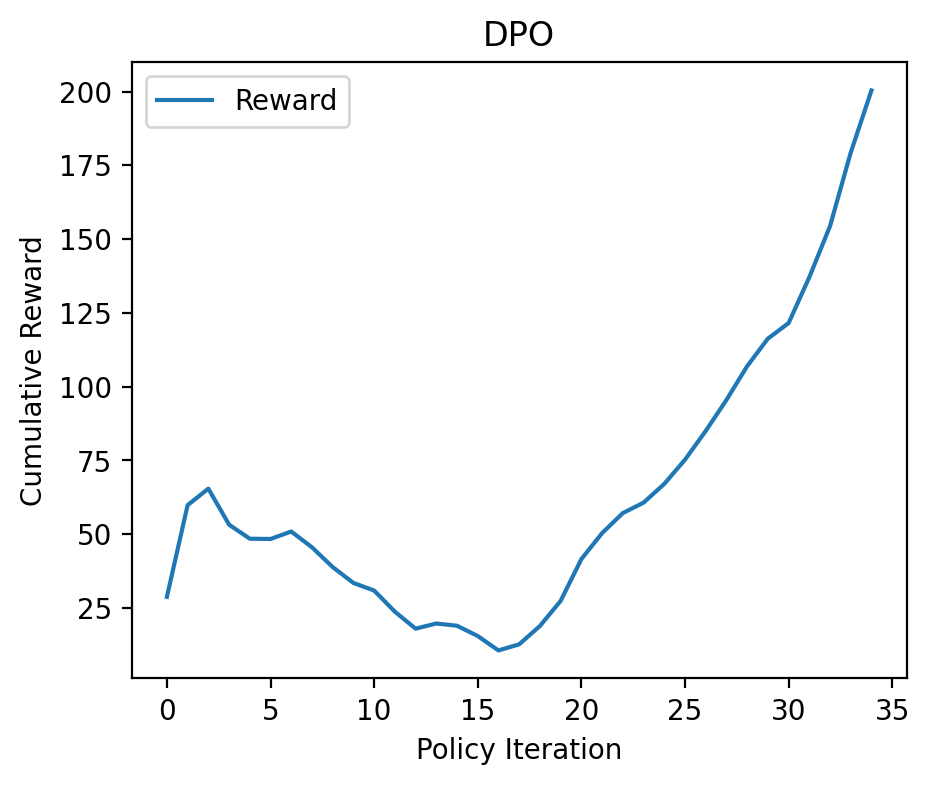

In [9]:
# For debugging, comment out for submission
# Comment out for submission
# Plot the return curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
ax.plot(reward_curve, label='Reward')
plt.xlabel('Policy Iteration')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.title('DPO')
plt.show()